# Hyperparameter Tuning and Optimization
## CSE Employability Skill Gap Prediction — 50,000 Records

This notebook adapts the Random Forest hyperparameter-tuning practical to the
`CSE_Employability_Skill_Gap_50000_Realistic` dataset.

Workflow:
1. Load and validate the dataset.
2. Select the employability/skill-gap target and prepare features.
3. Train a baseline Random Forest.
4. Tune it with Grid Search and Random Search.
5. Compare results, inspect configurations, save the final model, and log experiments with MLflow.

**Important:** Check the target column detected in Section 4. If your dataset uses a different label column, set `TARGET_COLUMN` to that exact column name.


## 1. Install required packages

In [ ]:
!pip -q install pandas scikit-learn matplotlib joblib mlflow openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1

## 2. Import libraries

In [2]:
import os
import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42


## 3. Upload the CSE employability dataset

Upload the CSV or Excel file named similar to `CSE_Employability_Skill_Gap_50000_Realistic`.
This loader supports `.csv`, `.xlsx`, and `.xls` files.


In [3]:

from google.colab import files

DATA_PATH = None
possible_paths = [
    "/content/CSE_Employability_Skill_Gap_50000_Realistic.csv",
    "/content/CSE_Employability_Skill_Gap_50000_Realistic.xlsx",
    "/content/CSE_Employability_Skill_Gap_50000_Realistic.xls",
]

for path in possible_paths:
    if os.path.exists(path):
        DATA_PATH = path
        break

if DATA_PATH is None:
    print("Upload your CSE_Employability_Skill_Gap_50000_Realistic dataset (CSV or Excel).")
    uploaded = files.upload()
    if not uploaded:
        raise ValueError("No file was uploaded.")
    DATA_PATH = "/content/" + next(iter(uploaded))

print("Using file:", DATA_PATH)


Upload your CSE_Employability_Skill_Gap_50000_Realistic dataset (CSV or Excel).


Saving CSE_Employability_Skill_Gap_50000_Realistic.xlsx to CSE_Employability_Skill_Gap_50000_Realistic.xlsx
Using file: /content/CSE_Employability_Skill_Gap_50000_Realistic.xlsx


## 4. Load and validate the dataset

In [4]:
if DATA_PATH.lower().endswith(".csv"):
    df = pd.read_csv(DATA_PATH)
elif DATA_PATH.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(DATA_PATH)
else:
    raise ValueError("Unsupported file format. Please upload a CSV or Excel file.")

# Clean column labels while preserving their names otherwise.
df.columns = df.columns.astype(str).str.strip()

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
display(df.head())

print("\nMissing values (top 20 columns):")
display(df.isnull().sum().sort_values(ascending=False).head(20))


Dataset shape: (50000, 101)

Column names:
['Student_ID', 'Age', 'Gender', 'Degree', 'Specialization', 'Current_Year', 'Semester', 'CGPA', 'Attendance_Percentage', 'Internal_Marks', 'External_Marks', 'Mini_Project_Score', 'Major_Project_Score', 'Lab_Performance', 'Assignment_Average', 'Backlogs', 'Academic_Consistency', 'Class_Rank', 'C_Programming', 'C++_Programming', 'Java', 'Python', 'JavaScript', 'SQL', 'HTML_CSS', 'ReactJS', 'NodeJS', 'Programming_Logic', 'Arrays', 'Linked_Lists', 'Stacks_Queues', 'Trees', 'Graphs', 'Dynamic_Programming', 'Searching_Sorting', 'Competitive_Coding', 'Statistics', 'Linear_Algebra', 'Machine_Learning', 'Deep_Learning', 'NLP', 'Computer_Vision', 'Data_Preprocessing', 'Feature_Engineering', 'Model_Evaluation', 'Data_Visualization', 'AWS', 'Azure', 'Google_Cloud', 'Docker', 'Kubernetes', 'MLflow', 'DVC', 'FastAPI', 'CI_CD', 'Model_Monitoring', 'MySQL', 'PostgreSQL', 'MongoDB', 'Firebase', 'REST_API', 'Spring_Boot', 'ExpressJS', 'API_Development', 'Git', 

,Student_ID,Age,Gender,Degree,Specialization,Current_Year,Semester,CGPA,Attendance_Percentage,Internal_Marks,...,LeetCode_Problems_Solved,HackerRank_Badge_Level,Certifications,Hackathons_Attended,Resume_Score,Aptitude_Score,Technical_Interview_Score,HR_Interview_Score,Mock_Interview_Score,Skill_Gap_Level
0,CSE000001,24,Female,B.Tech,AI & ML,2,3,9.78,100,79,...,0,Gold,12,7,81,51,65,54,57,Medium
1,CSE000002,20,Female,B.Tech,Cyber Security,3,5,5.99,91,100,...,604,Gold,8,9,55,67,35,35,37,High
2,CSE000003,23,Female,B.Tech,Data Science,3,5,6.82,95,45,...,612,Silver,7,6,75,81,35,35,35,Medium
3,CSE000004,19,Other,B.Tech,Cloud Computing,3,6,8.93,77,69,...,783,Silver,6,6,69,82,46,40,45,High
4,CSE000005,23,Male,B.Tech,AI & ML,3,5,9.25,70,69,...,97,Bronze,2,10,83,96,59,52,57,Medium



Missing values (top 20 columns):


,0
HackerRank_Badge_Level,10083
Age,0
Gender,0
Degree,0
Student_ID,0
Current_Year,0
Semester,0
CGPA,0
Attendance_Percentage,0
Internal_Marks,0


## 5. Select features and target

## 5. Select the target and prepare features

The target is the value the model learns to predict. The code checks common target names.
If none matches, it stops and displays the columns so you can set `TARGET_COLUMN` manually.

For example, if your dataset's label column is `Employability_Status`, leave the default
selection. Do not use a student ID or a column that is only an identifier as the target.


In [5]:
# Set this to the exact target/label column name in your dataset if needed.
TARGET_COLUMN = None

target_candidates = [
    "Employability_Status",
    "Employability_Label",
    "Employability_Class",
    "Employability_Category",
    "Employability",
    "Skill_Gap_Level",
    "Skill_Gap_Category",
    "Skill_Gap_Status",
    "Employability_Score",
    "Target",
    "Label",
]

if TARGET_COLUMN is None:
    normalized_columns = {c.lower().replace(" ", "_"): c for c in df.columns}
    for candidate in target_candidates:
        key = candidate.lower().replace(" ", "_")
        if key in normalized_columns:
            TARGET_COLUMN = normalized_columns[key]
            break

if TARGET_COLUMN is None:
    raise ValueError(
        "Could not automatically identify the target column.\n"
        "Set TARGET_COLUMN to the exact label column name and rerun this cell.\n"
        f"Available columns: {df.columns.tolist()}"
    )

if TARGET_COLUMN not in df.columns:
    raise ValueError(f"TARGET_COLUMN '{TARGET_COLUMN}' is not in the dataset.")

# Remove rows without a known target value.
df = df.dropna(subset=[TARGET_COLUMN]).copy()

# Drop common ID-like columns from predictors to avoid learning record identifiers.
id_columns = [
    c for c in df.columns
    if c.lower().strip() in {
        "student_id", "studentid", "id", "record_id", "index", "unnamed: 0"
    }
]
feature_columns = [c for c in df.columns if c != TARGET_COLUMN and c not in id_columns]

if not feature_columns:
    raise ValueError("No feature columns remain after excluding target and ID columns.")

X = df[feature_columns].copy()
y = df[TARGET_COLUMN].copy()

# Convert boolean predictors to integer values for consistent preprocessing.
for col in X.select_dtypes(include=["bool"]).columns:
    X[col] = X[col].astype(int)

# This notebook uses classification. If the target is a continuous numeric score,
# create meaningful categories or use a regression model instead.
if y.nunique() < 2:
    raise ValueError(f"Target '{TARGET_COLUMN}' has fewer than two classes.")
if pd.api.types.is_numeric_dtype(y) and y.nunique() > 30:
    print(
        "WARNING: The target is numeric with many unique values. "
        "If this is a continuous score, a regression model may be more appropriate."
    )

print("Target column:", TARGET_COLUMN)
print("Number of predictor columns:", len(feature_columns))
print("Excluded ID columns:", id_columns)
print("Target classes / values:", y.nunique())
print("\nTarget distribution:")
display(y.value_counts(dropna=False).rename("count").to_frame())


Target column: Skill_Gap_Level
Number of predictor columns: 99
Excluded ID columns: ['Student_ID']
Target classes / values: 3

Target distribution:


,count
Skill_Gap_Level,
High,37154
Medium,12186
Low,660


In [6]:
# Stratify only when every class has enough examples for the split.
class_counts = y.value_counts()
stratify_target = y if class_counts.min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=stratify_target
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))


Training records: 40000
Testing records: 10000


## 6. Split into training and test data

The test set is held out and is not used by Grid Search or Random Search to select hyperparameters.
For a classification target, stratification preserves class proportions when possible.


In [7]:
numerical_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numerical_features]

numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

transformers = []
if numerical_features:
    transformers.append(("numerical", numerical_pipeline, numerical_features))
if categorical_features:
    transformers.append(("categorical", categorical_pipeline, categorical_features))

preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

print("Numeric features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Preprocessing pipeline created.")


Numeric features: 95
Categorical features: 4
Preprocessing pipeline created.


## 7. Build the preprocessing pipeline

Numeric columns are imputed with the median. Categorical columns are imputed with the
most frequent value and one-hot encoded. Columns are detected automatically, so the
pipeline can handle the dataset's academic, programming, DSA, AI/ML, cloud, and MLOps fields.


In [8]:
baseline_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

baseline_start = time.time()
baseline_pipeline.fit(X_train, y_train)
baseline_runtime = time.time() - baseline_start

baseline_predictions = baseline_pipeline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Baseline test accuracy:", round(baseline_accuracy, 4))
print("Baseline runtime (seconds):", round(baseline_runtime, 2))
print("\nClassification report:")
print(classification_report(y_test, baseline_predictions, zero_division=0))


Baseline test accuracy: 0.9316
Baseline runtime (seconds): 12.89

Classification report:
              precision    recall  f1-score   support

        High       0.95      0.98      0.96      7431
         Low       1.00      0.08      0.15       132
      Medium       0.88      0.83      0.86      2437

    accuracy                           0.93     10000
   macro avg       0.94      0.63      0.66     10000
weighted avg       0.93      0.93      0.93     10000



# Part B - Grid Search

Grid Search evaluates every combination in the specified search grid using 5-fold cross-validation on the training data.

In [9]:
rf_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 15, 30],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

number_of_grid_combinations = 1
for values in param_grid.values():
    number_of_grid_combinations *= len(values)

print("Grid combinations:", number_of_grid_combinations)
print("Approximate model fits with 5-fold CV:", number_of_grid_combinations * 5)
print("Note: with 50,000 records, hyperparameter tuning may take some time.")


Grid combinations: 24
Approximate model fits with 5-fold CV: 120
Note: with 50,000 records, hyperparameter tuning may take some time.


In [10]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_start = time.time()
grid_search.fit(X_train, y_train)
grid_runtime = time.time() - grid_start

print("Best Grid Search parameters:")
print(grid_search.best_params_)
print("Best Grid Search CV accuracy:", round(grid_search.best_score_, 4))
print("Grid Search runtime (seconds):", round(grid_runtime, 2))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Grid Search parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best Grid Search CV accuracy: 0.9224
Grid Search runtime (seconds): 1843.48


## 8. Evaluate the Grid Search model on the untouched test set

In [11]:
grid_best_model = grid_search.best_estimator_
grid_predictions = grid_best_model.predict(X_test)
grid_accuracy = accuracy_score(y_test, grid_predictions)

print("Grid Search test accuracy:", round(grid_accuracy, 4))
print("\nClassification report:")
print(classification_report(y_test, grid_predictions, zero_division=0))


Grid Search test accuracy: 0.9313

Classification report:
              precision    recall  f1-score   support

        High       0.95      0.98      0.96      7431
         Low       1.00      0.05      0.10       132
      Medium       0.88      0.83      0.86      2437

    accuracy                           0.93     10000
   macro avg       0.94      0.62      0.64     10000
weighted avg       0.93      0.93      0.93     10000



# Part C - Random Search

Random Search samples a fixed number of configurations from a larger search space. It is useful when evaluating every possible combination would be expensive.

In [12]:
param_distributions = {
    "model__n_estimators": [100, 150, 200, 300, 400],
    "model__max_depth": [None, 10, 15, 20, 30, 40],
    "model__min_samples_split": [2, 4, 6, 8, 10],
    "model__min_samples_leaf": [1, 2, 4, 6],
    "model__max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring="accuracy",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

random_start = time.time()
random_search.fit(X_train, y_train)
random_runtime = time.time() - random_start

print("Best Random Search parameters:")
print(random_search.best_params_)
print("Best Random Search CV accuracy:", round(random_search.best_score_, 4))
print("Random Search runtime (seconds):", round(random_runtime, 2))


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Random Search parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': None}
Best Random Search CV accuracy: 0.9738
Random Search runtime (seconds): 3084.79


## 9. Evaluate the Random Search model on the untouched test set

In [13]:
random_best_model = random_search.best_estimator_
random_predictions = random_best_model.predict(X_test)
random_accuracy = accuracy_score(y_test, random_predictions)

print("Random Search test accuracy:", round(random_accuracy, 4))
print("\nClassification report:")
print(classification_report(y_test, random_predictions, zero_division=0))


Random Search test accuracy: 0.9776

Classification report:
              precision    recall  f1-score   support

        High       0.99      0.99      0.99      7431
         Low       0.97      0.56      0.71       132
      Medium       0.94      0.97      0.95      2437

    accuracy                           0.98     10000
   macro avg       0.97      0.84      0.89     10000
weighted avg       0.98      0.98      0.98     10000



# Part D - Compare Baseline, Grid Search, and Random Search

In [14]:
comparison_df = pd.DataFrame({
    "Method": ["Baseline", "Grid Search", "Random Search"],
    "CV Accuracy": [None, grid_search.best_score_, random_search.best_score_],
    "Test Accuracy": [baseline_accuracy, grid_accuracy, random_accuracy],
    "Runtime Seconds": [baseline_runtime, grid_runtime, random_runtime]
})

comparison_df["Test Accuracy (%)"] = comparison_df["Test Accuracy"] * 100
comparison_df["Improvement vs Baseline (pp)"] = (
    comparison_df["Test Accuracy"] - baseline_accuracy
) * 100

display(comparison_df.round(4))

,Method,CV Accuracy,Test Accuracy,Runtime Seconds,Test Accuracy (%),Improvement vs Baseline (pp)
0,Baseline,NaN,0.9316,12.8943,93.16,0.00
1,Grid Search,0.9224,0.9313,1843.4834,93.13,-0.03
2,Random Search,0.9738,0.9776,3084.7912,97.76,4.60


## 10. Visualize test accuracy before and after tuning

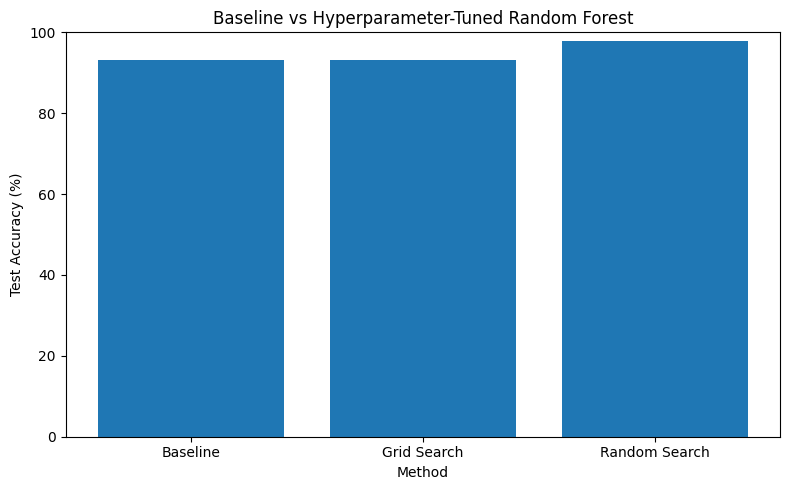

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Method"], comparison_df["Test Accuracy (%)"])
plt.ylabel("Test Accuracy (%)")
plt.xlabel("Method")
plt.title("Baseline vs Hyperparameter-Tuned Random Forest")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## 11. Inspect the best Grid Search configurations

In [16]:
grid_results = pd.DataFrame(grid_search.cv_results_)

grid_result_table = grid_results[[
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__min_samples_split",
    "param_model__min_samples_leaf",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

grid_result_table = grid_result_table.sort_values(
    ["rank_test_score", "mean_test_score"],
    ascending=[True, False]
).reset_index(drop=True)

display(grid_result_table.head(10))

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,mean_test_score,std_test_score,rank_test_score
0,200,None,5,1,0.922375,0.003761,1
1,200,30,5,1,0.922250,0.003679,2
2,200,30,2,1,0.922000,0.003553,3
3,100,30,5,1,0.921625,0.002945,4
4,200,None,2,1,0.921525,0.003347,5
5,100,None,5,1,0.921150,0.003601,6
6,200,None,2,2,0.920675,0.004289,7
7,200,30,2,2,0.920350,0.003280,8
8,100,30,5,2,0.919950,0.002801,9
9,200,None,5,2,0.919825,0.003214,10


## 12. Visualize the top 10 Grid Search configurations

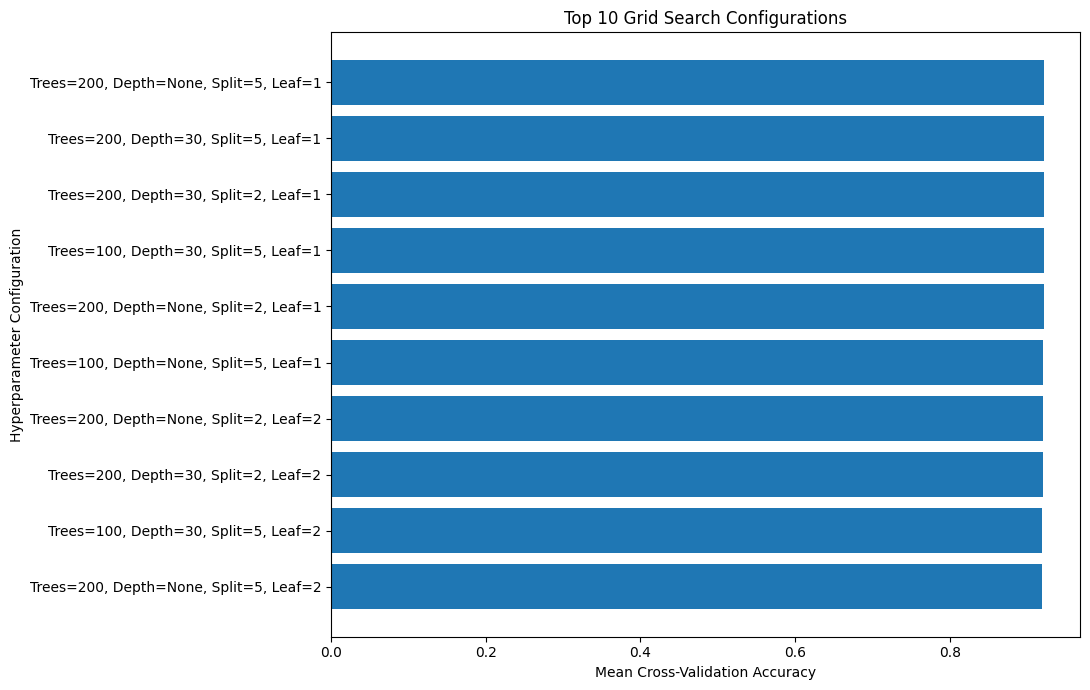

In [17]:

top_grid = grid_result_table.head(10).copy()

top_grid["Configuration"] = (
    "Trees=" + top_grid["param_model__n_estimators"].astype(str)
    + ", Depth=" + top_grid["param_model__max_depth"].astype(str)
    + ", Split=" + top_grid["param_model__min_samples_split"].astype(str)
    + ", Leaf=" + top_grid["param_model__min_samples_leaf"].astype(str)
)

# Reverse only for display so the best configuration appears at the top.
top_grid_plot = top_grid.iloc[::-1]

plt.figure(figsize=(11, 7))
plt.barh(top_grid_plot["Configuration"], top_grid_plot["mean_test_score"])
plt.xlabel("Mean Cross-Validation Accuracy")
plt.ylabel("Hyperparameter Configuration")
plt.title("Top 10 Grid Search Configurations")
plt.tight_layout()
plt.show()

## 13. Inspect the best Random Search configurations

In [18]:
random_results = pd.DataFrame(random_search.cv_results_)

random_result_table = random_results[[
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__min_samples_split",
    "param_model__min_samples_leaf",
    "param_model__max_features",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

random_result_table = random_result_table.sort_values(
    ["rank_test_score", "mean_test_score"],
    ascending=[True, False]
).reset_index(drop=True)

display(random_result_table.head(10))

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,mean_test_score,std_test_score,rank_test_score
0,200,None,10,2,None,0.973775,0.002182,1
1,400,40,8,1,None,0.973600,0.001853,2
2,400,15,8,4,None,0.973350,0.002072,3
3,400,10,2,2,None,0.972925,0.001250,4
4,400,10,2,4,None,0.972500,0.001457,5
5,150,10,8,6,None,0.970700,0.001320,6
6,100,30,2,2,sqrt,0.915500,0.002129,7
7,400,20,4,1,sqrt,0.913350,0.002815,8
8,300,20,8,2,sqrt,0.911825,0.003648,9
9,150,20,2,1,sqrt,0.911150,0.003600,10


# Part E - Report the Impact of Tuning

In [19]:
grid_improvement_pp = (grid_accuracy - baseline_accuracy) * 100
random_improvement_pp = (random_accuracy - baseline_accuracy) * 100

print("Baseline test accuracy:      {:.2f}%".format(baseline_accuracy * 100))
print("Grid Search test accuracy:   {:.2f}%".format(grid_accuracy * 100))
print("Random Search test accuracy: {:.2f}%".format(random_accuracy * 100))
print()
print("Grid Search impact:   {:+.2f} percentage points".format(grid_improvement_pp))
print("Random Search impact: {:+.2f} percentage points".format(random_improvement_pp))

if grid_improvement_pp > 0:
    print("Grid Search improved test accuracy.")
elif grid_improvement_pp < 0:
    print("Grid Search reduced test accuracy; the best CV configuration did not generalize better to this test split.")
else:
    print("Grid Search produced no change in test accuracy.")

if random_improvement_pp > 0:
    print("Random Search improved test accuracy.")
elif random_improvement_pp < 0:
    print("Random Search reduced test accuracy; the best CV configuration did not generalize better to this test split.")
else:
    print("Random Search produced no change in test accuracy.")

Baseline test accuracy:      93.16%
Grid Search test accuracy:   93.13%
Random Search test accuracy: 97.76%

Grid Search impact:   -0.03 percentage points
Random Search impact: +4.60 percentage points
Grid Search reduced test accuracy; the best CV configuration did not generalize better to this test split.
Random Search improved test accuracy.


## 14. Select and save the final model

Selection below is based on test accuracy only for this classroom comparison. In a production workflow, model promotion should also consider validation protocol, calibration, robustness, latency, resource usage, fairness, and operational requirements.

In [20]:
model_candidates = {
    "Baseline": (baseline_accuracy, baseline_pipeline),
    "Grid Search": (grid_accuracy, grid_best_model),
    "Random Search": (random_accuracy, random_best_model)
}

best_method = max(model_candidates, key=lambda name: model_candidates[name][0])
final_accuracy, final_model = model_candidates[best_method]

FINAL_MODEL_PATH = "/content/best_cse_employability_random_forest.joblib"
joblib.dump(final_model, FINAL_MODEL_PATH)

print("Selected method:", best_method)
print("Selected test accuracy: {:.2f}%".format(final_accuracy * 100))
print("Saved model:", FINAL_MODEL_PATH)


Selected method: Random Search
Selected test accuracy: 97.76%
Saved model: /content/best_cse_employability_random_forest.joblib


## 15. Load the saved model and make a prediction

In [21]:
loaded_model = joblib.load(FINAL_MODEL_PATH)

# Demonstration prediction using one held-out record.
# Replace this row with a new student's values when you are ready to predict.
sample_student = X_test.iloc[[0]].copy()
actual_value = y_test.iloc[0]
prediction = loaded_model.predict(sample_student)[0]

print("Actual target:", actual_value)
print("Predicted target:", prediction)
display(sample_student)


Actual target: Medium
Predicted target: Medium


,Age,Gender,Degree,Specialization,Current_Year,Semester,CGPA,Attendance_Percentage,Internal_Marks,External_Marks,...,GitHub_Repositories,LeetCode_Problems_Solved,HackerRank_Badge_Level,Certifications,Hackathons_Attended,Resume_Score,Aptitude_Score,Technical_Interview_Score,HR_Interview_Score,Mock_Interview_Score
20377,20,Male,B.Tech,Cyber Security,2,4,8.65,89,52,69,...,12,26,Silver,8,7,76,95,58,49,52


# Part F - Optional MLflow Integration

This section logs the baseline, best Grid Search model, and best Random Search model as three MLflow runs. It is included because experiment tracking is part of the same MLOps unit.

In [22]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("sqlite:////content/mlflow_cse_employability_hpo.db")
mlflow.set_experiment("CSE Employability Skill Gap - Hyperparameter Tuning")

print("Tracking URI:", mlflow.get_tracking_uri())


2026/10/02 07:53:32 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/02 07:53:32 INFO mlflow.store.db.utils: Updating database tables
2026/10/02 07:53:36 INFO mlflow.tracking.fluent: Experiment with name 'CSE Employability Skill Gap - Hyperparameter Tuning' does not exist. Creating a new experiment.


Tracking URI: sqlite:////content/mlflow_cse_employability_hpo.db


In [23]:
def log_hpo_run(run_name, tuning_method, model_object, test_accuracy, cv_accuracy=None, best_params=None):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("model", "RandomForestClassifier")
        mlflow.log_param("tuning_method", tuning_method)

        if best_params:
            mlflow.log_params({f"best_{k.replace('model__', '')}": v for k, v in best_params.items()})

        mlflow.log_metric("test_accuracy", float(test_accuracy))
        if cv_accuracy is not None:
            mlflow.log_metric("best_cv_accuracy", float(cv_accuracy))

        mlflow.sklearn.log_model(
            sk_model=model_object,
            name="model",
            serialization_format="cloudpickle"
        )

log_hpo_run(
    "RF_Baseline",
    "None",
    baseline_pipeline,
    baseline_accuracy
)

log_hpo_run(
    "RF_GridSearch",
    "GridSearchCV",
    grid_best_model,
    grid_accuracy,
    grid_search.best_score_,
    grid_search.best_params_
)

log_hpo_run(
    "RF_RandomSearch",
    "RandomizedSearchCV",
    random_best_model,
    random_accuracy,
    random_search.best_score_,
    random_search.best_params_
)

print("MLflow runs logged successfully.")

2026/10/02 07:53:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/02 07:53:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/02 07:54:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

MLflow runs logged successfully.


## 16. Display the MLflow comparison table

In [24]:
experiment = mlflow.get_experiment_by_name(
    "CSE Employability Skill Gap - Hyperparameter Tuning"
)
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

columns = [
    "tags.mlflow.runName",
    "params.tuning_method",
    "metrics.best_cv_accuracy",
    "metrics.test_accuracy"
]

available_columns = [c for c in columns if c in runs.columns]
if available_columns:
    display(runs[available_columns].sort_values("metrics.test_accuracy", ascending=False))
else:
    display(runs)


,tags.mlflow.runName,params.tuning_method,metrics.best_cv_accuracy,metrics.test_accuracy
0,RF_RandomSearch,RandomizedSearchCV,0.973775,0.9776
2,RF_Baseline,None,NaN,0.9316
1,RF_GridSearch,GridSearchCV,0.922375,0.9313


# Interpretation

- **Baseline** gives the reference performance before tuning.
- **Grid Search** evaluates every specified combination in the grid.
- **Random Search** samples a fixed number of configurations from a larger search space.
- **Cross-validation accuracy** is used to select hyperparameters without repeatedly using the test set.
- **Test accuracy** is used for final evaluation after model selection.
- A tuned model is not guaranteed to improve the final test accuracy. A negative or zero change is a valid experimental result.